# Finnish Twittersphere 

# Introduzione 
L'obiettivo della nostra ricerca è analizzare le dinamiche di interazione su Twitter in occasione delle elezioni politiche finlandesi. Abbiamo a disposizione 5 topic di discussione (Clima, Economia, Immigrazione, Sicurezza, Educazione) relativi alle due settimane precendenti le elezioni politiche del 2019 e 2023. Le reti sono indirette, non pesate e connesse. Ogni nodo rappresenta un utente twitter e ogni link l'interazione di retweet.

Dal gruppo di ricerca [(Salloum A., 2025)](https://www.cambridge.org/core/journals/network-science/article/anatomy-of-elite-and-mass-polarization-in-social-networks/FD754F5AB8AB1434D20B6DC7F49BC2B1), sono state riconosciute due comunità tramite un algoritmo che utilizza un Planted Partition Model minimizzando la Minimum Description Length. Tali comunità sono state identificate con l'appartenenzza ai due schieramenti politici principali: destra e sinistra. Quindi ogni nodo presenta una label: "A" se appartiene allo schieramento di sinistra, "B" se di destra.

## Indice
- **Capitolo 1**: Analisi di alcune metriche globali delle reti per identificare la rete e i temi più rilevanti per il nostro studio;
- **Capitolo 2**: Studio della rete scelta *(Immigrazione 2023)*:
    - Studio delle distribuzione delle centralità confrontanto le due comunità;
    - Analisi della polarizzazione della rete con confronto con modelli nulli;
    - Analisi dei bridge che collegano le due comunità.
- **Capitolo 3**: Simulazione di un modello di segregazione, per riprodurre la polarizzazione osservata tra le comunità.
- **Visualizzazione**: Visualizzazione dinamica di reti utili per confermare le nostre analisi.

In [1]:
from utils import *
from visualization_utils import *
import matplotlib.pyplot as plt
import numpy as np
import igraph as ig
import pandas as pd

# Metriche Globali
Abbiamo valutato per le 10 reti in esame il valore di assortatività e il numero di nodi presenti in ogni comunità. La rete che abbiamo selezionato è quella che presenta maggior valore di assortatività e numero di nodi equalmente distibuito tra comunità, così da avere una divisione in comunità più netta e bilanciata, in cui entrambi gli scheramenti sono ben rappresentati.

In [4]:
rows = []

for (name, year) in zip(GRAPH_FILENAMES, YEARS):
    
    graph_path = DATA_DIR + name
    G = load_graph(graph_path)
    n_A, n_B, _, _,= communities_statistics(G)
    group_label = [1 if v == 'A' else 0 for v in G.vs['group']]
    assortativita = G.assortativity_nominal(types=group_label, directed=False)
    eiindex = ei_index(G, group_label)
    dati = {
        'Nome Grafo': name,
        'Ei Index': eiindex,
        'Assortatività': assortativita,
        'nodi di A': n_A,
        'nodi di B': n_B,
        'Anno': year}
    rows.append(dati)

df = pd.DataFrame(rows)


Text(0.5, 0.98, 'Confronto tra le 10 reti')

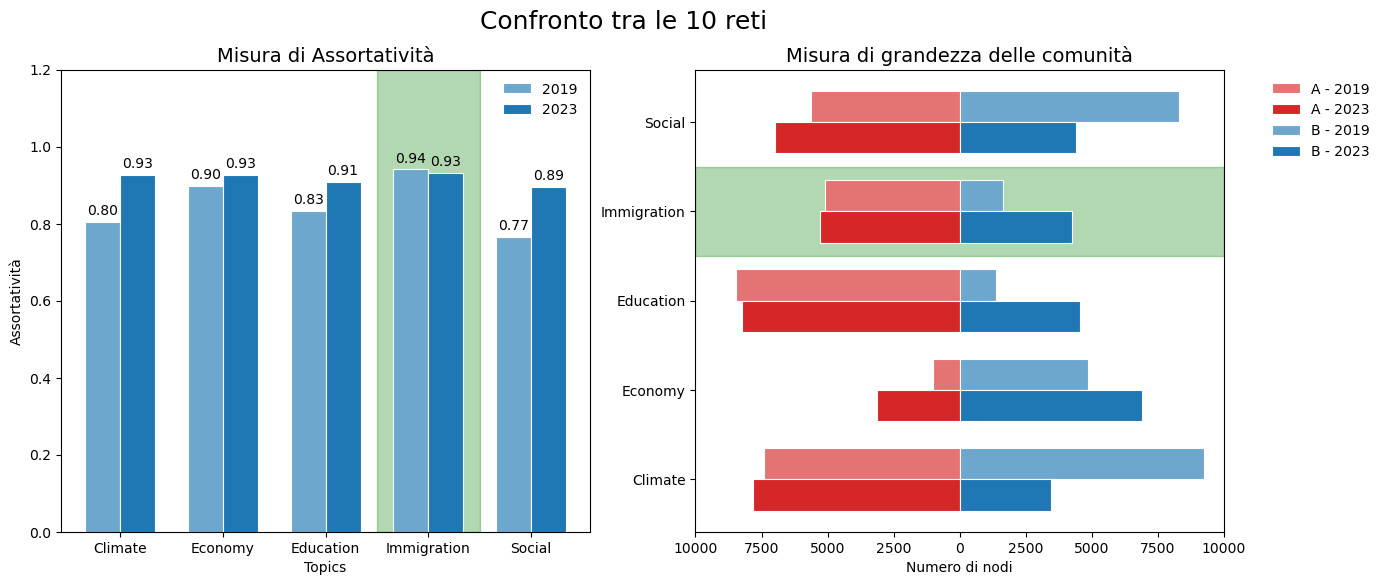

In [7]:
fig, axs = plt.subplots(1, 2, figsize=FIGSIZE_LARGE)
df_2019 = df[df['Anno'] == 2019]
df_2023 = df[df['Anno'] == 2023]
x = np.arange(len(TOPIC))
width = 0.34    

y2019 = axs[0].bar(x - width / 2, df_2019['Assortatività'], width, color=lighten_color(cmap(0)), edgecolor='white', linewidth=0.8, label='2019')
y2023 = axs[0].bar(x + width / 2, df_2023['Assortatività'], width, color=cmap(0),edgecolor='white', linewidth=0.8, label='2023')

axs[0].bar_label(y2019, padding=3, fmt='%.2f')
axs[0].bar_label(y2023, padding=3, fmt='%.2f')
axs[0].set_xticks(x)
axs[0].set_xticklabels(TOPIC)
axs[0].set_ylim(0, 1.2)
axs[0].axvspan(3 - 0.5, 3 + 0.5, color='green',alpha=0.3, zorder=0)
axs[0].set_title("Misura di Assortatività", fontsize=FONTSIZE_TITLE)
axs[0].legend(frameon=False, bbox_to_anchor=(1, 1.0), loc='upper right')

axs[0].set_xlabel("Topics")
axs[0].set_ylabel("Assortatività")

height = 0.35
axs[1].barh(x + height/2, -df_2019['nodi di A'], height=height,
        color=lighten_color(color_group['A']), edgecolor='white', linewidth=0.8, label='A - 2019')
axs[1].barh(x - height/2, -df_2023['nodi di A'], height=height,
        color=color_group['A'], edgecolor='white', linewidth=0.8, label='A - 2023')
axs[1].barh(x + height/2, df_2019['nodi di B'], height=height,
        color=lighten_color(color_group['B']), edgecolor='white', linewidth=0.8, label='B - 2019')

axs[1].barh(x - height/2, df_2023['nodi di B'], height=height,
        color=color_group['B'], edgecolor='white', linewidth=0.8, label='B - 2023')
axs[1].set_yticks(x)
axs[1].set_xticks([-10000,-7500,-5000, -2500, 0, 2500, 5000, 7500, 10000])
axs[1].set_xticklabels(['10000','7500','5000', '2500', '0', '2500', '5000', '7500', '10000'])
axs[1].set_xlim(-10000,10000)
axs[1].axhspan(3 - 0.5, 3 + 0.5, color='green',alpha=0.3, zorder=0)
axs[1].set_yticklabels(TOPIC)
axs[1].set_title("Misura di grandezza delle comunità", fontsize=FONTSIZE_TITLE)
axs[1].set_xlabel("Numero di nodi")
axs[1].legend(frameon=False, bbox_to_anchor=(1.3,1), loc='upper right')

plt.suptitle("Confronto tra le 10 reti", fontsize=FONTSIZE_SUPTITLE)

La rete scelta che soddisfa le richieste è quella relativa al tema dell'immigrazione dell'anno 2023. 

In [8]:
graph_path = CENTRALITY_DIR + 'Centrality_immigration_23.graphml'
G = load_graph(graph_path)

c:\Users\maria\Desktop\Analisi e visualizzazione reti complesse\AVRC_FinnishTwittersphereProject\Consegna finale\utils.py:29: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


**Immigrazione 2023**

Riportiamo le metriche globali della rete scelta, confrontando con due reti generate dai modelli di Erdos Reyni e Barabasi Albert vincolati ai parametri della rete originale.

In [9]:
stat = network_statistics(G)
# genero grafo con Erdos Renyi e Barabasi Albert
G_er = ig.Graph.Erdos_Renyi(n=stat['Numero di Nodi'], m=stat['Numero di Archi'])
G_ba = ig.Graph.Barabasi(stat['Numero di Nodi'], max(1, round(stat['Grado Medio'] / 2)))

pd.DataFrame([stat, network_statistics(G_er), network_statistics(G_ba)], index=['Grafo Reale','ER','BA'])

,Numero di Nodi,Numero di Archi,Densità del Grafo,Grado Medio,Clustering Medio,Diametro,Cammino Medio
Grafo Reale,9519,36889,0.000814,7.750604,0.117528,13,4.166688
ER,9519,36889,0.000814,7.750604,0.000765,9,4.705324
BA,9519,38066,0.000840,7.997899,0.004916,6,3.962182


La rete è sparsa, presenta un coefficiente di clustering molto più alto rispetto ai modelli nulli considerati, in accordo con le dinamiche sociali di chiusura triadrica. Si verifica il fenomeno small-world. Infatti:  

In [10]:
logN = np.log(stat['Numero di Nodi']) 
print(f"APL = {stat['Cammino Medio']:.2f} < log(N) = {logN:.2f}")

APL = 4.17 < log(N) = 9.16


Confrontiamo per i tre grafi la **Comulative Complementary Distribution Function** e il **Rank** dei nodi riferito al grado.

In [16]:
G_er.vs['degree'] = G_er.degree()
G_ba.vs['degree'] = G_ba.degree()
G.vs['degree'] = G.degree()

def plot_ccdf_random_model(G: ig.Graph | list[ig.Graph], metric: str='degree', log: bool=True, savefile='', title='', legend=None):
    
    if isinstance(G, ig.Graph):
        G = [G]
    if legend is None:
        legend = [str(i) for i in range(1,len(G)+1)]
        
    fig, ax = plt.subplots(1,2, figsize=FIGSIZE_LARGE)
    for graph, color, label in zip(G, (cmap(0), cmap(1), cmap(2)), legend):
        values = np.array(graph.vs[metric])
        values = np.sort(values)[::-1]
        k_values, ccdf = compute_ccdf(values)
        ax[0].plot(k_values, ccdf, marker='o', markersize=1, linewidth=0.8, color = color, label=label)
        ax[0].set_xlabel(metric.capitalize())
        ax[0].set_ylabel('CCDF')
        if log:
            ax[0].set_xscale('log')
            ax[0].set_yscale('log')
        ax[1].plot(np.arange(1,len(values)+1), values, marker='o', markersize=1, linewidth=0.8, color = color, label=label)
        ax[1].set_ylabel(metric.capitalize())
        ax[1].set_xlabel('Rank')    
        

        if log:
            ax[1].set_xscale('log')
            ax[1].set_yscale('log')

    ax[0].legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    ax[0].set_title('CCDF - ' + metric.capitalize(), fontsize=FONTSIZE_TITLE)
    ax[1].set_title(metric.capitalize() + ' - Rank', fontsize=FONTSIZE_TITLE)
    ax[1].legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')   
    
    if title:
        fig.suptitle(title)
    else:
        fig.suptitle('Confronto con modelli nulli', fontsize=FONTSIZE_SUPTITLE)
    if savefile:
        plt.savefig(savefile)
    else:
        plt.show()

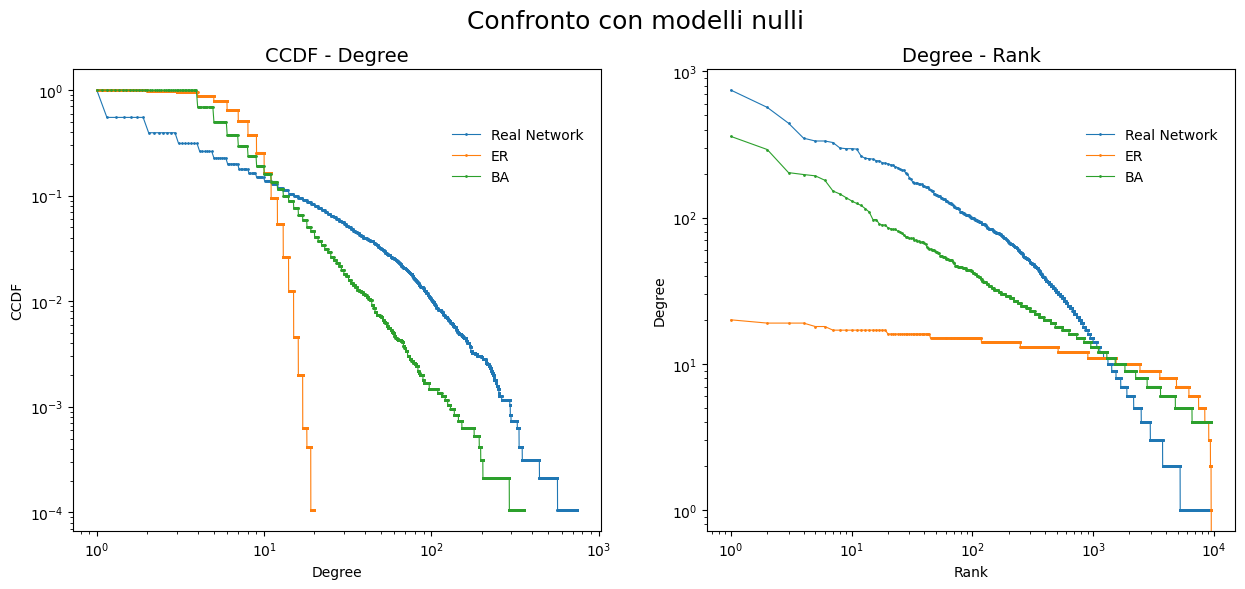

In [17]:
plot_ccdf_random_model([G, G_er, G_ba], metric='degree', legend=('Real Network', 'ER', 'BA'))

Dal grafico sulla destra, notiamo come la distribuzione dei gradi della nostra rete risulti maggiormente eterogenea rispetto alle altre. Mentre la CCDF ci mostra che la distribuzione del grado è a *coda pesante*, con una pendenza inferiore di quella generata da Barabasi-Albert.

# Conclusione
La rete mostra le classiche caratteristiche di una rete reale:
- Alto coefficiente di clustering;
- Effetto small-world;
- Distribuzione del grado eterogenea (a coda pesante).

Procederemo nei prossimi capitoli ad analizzare la struttura interna alle comunità e la loro interazione, quantificando la polarizzazione e interrogandoci sui fenomeni che vi contribuiscono.

In [ ]:
plt.close('all')